In [1]:
from google.colab import files

uploaded = files.upload()

Saving DataSet_LakaLantas_2025.xlsx to DataSet_LakaLantas_2025.xlsx


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_excel("/content/DataSet_LakaLantas_2025.xlsx")

In [4]:
df.head()

,No,Usia_Korban,Jenis_Kelamin,Jam_Kejadian,Waktu,Jenis_Kendaraan,Kondisi_Cuaca,Jenis_Jalan,Penggunaan_Alat_Keselamatan,Kecepatan_Kmh,Jumlah_Kendaraan_Terlibat,Kategori_Keparahan
0,1,14,Laki-laki,7,Pagi,Sepeda Motor,Hujan,Jalan Raya Antarkota,Tidak,73,1,Meninggal Dunia
1,2,19,Laki-laki,17,Sore,Sepeda Motor,Cerah,Jalan Raya Antarkota,Ya,36,1,Luka Ringan
2,3,41,Perempuan,8,Pagi,Sepeda Motor,Berkabut,Jalan Perkotaan,Ya,58,2,Meninggal Dunia
3,4,48,Perempuan,3,Malam,Sepeda,Cerah,Jalan Raya Antarkota,Tidak,10,2,Luka Ringan
4,5,13,Laki-laki,9,Pagi,Sepeda,Hujan,Jalan Pedesaan,Ya,10,1,Luka Berat


In [5]:
df = df.drop(columns=["No"])

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Usia_Korban                  300 non-null    int64
 1   Jenis_Kelamin                300 non-null    int64
 2   Jam_Kejadian                 300 non-null    int64
 3   Waktu                        300 non-null    int64
 4   Jenis_Kendaraan              300 non-null    int64
 5   Kondisi_Cuaca                300 non-null    int64
 6   Jenis_Jalan                  300 non-null    int64
 7   Penggunaan_Alat_Keselamatan  300 non-null    int64
 8   Kecepatan_Kmh                300 non-null    int64
 9   Jumlah_Kendaraan_Terlibat    300 non-null    int64
 10  Kategori_Keparahan           300 non-null    int64
dtypes: int64(11)
memory usage: 25.9 KB
None


In [10]:
df.describe()

,Usia_Korban,Jenis_Kelamin,Jam_Kejadian,Waktu,Jenis_Kendaraan,Kondisi_Cuaca,Jenis_Jalan,Penggunaan_Alat_Keselamatan,Kecepatan_Kmh,Jumlah_Kendaraan_Terlibat,Kategori_Keparahan
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,32.223333,0.263333,11.993333,1.216667,2.406667,1.240000,1.406667,0.543333,50.036667,2.026667,1.033333
std,15.939270,0.441178,6.816758,1.186486,1.103940,0.580393,0.904072,0.498951,24.767318,0.829608,0.895299
min,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000,0.000000
25%,20.000000,0.000000,6.750000,0.000000,1.000000,1.000000,1.000000,0.000000,31.750000,1.000000,0.000000
50%,28.000000,0.000000,12.000000,1.000000,3.000000,1.000000,1.000000,1.000000,47.500000,2.000000,1.000000
75%,42.000000,1.000000,18.000000,2.000000,3.000000,2.000000,2.000000,1.000000,64.000000,2.000000,2.000000
max,78.000000,1.000000,23.000000,3.000000,4.000000,2.000000,3.000000,1.000000,132.000000,4.000000,2.000000


In [12]:
ringkasan_model = pd.DataFrame({
    "Komponen": [
        "Algoritma",
        "Jumlah Tetangga (K)",
        "Distance Metric",
        "Weight",
        "Jumlah Fitur",
        "Jumlah Data Training",
        "Jumlah Data Testing"
    ],
    "Nilai": [
        "K-Nearest Neighbor",
        knn.n_neighbors,
        knn.metric,
        knn.weights,
        X_train.shape[1],
        X_train.shape[0],
        X_test.shape[0]
    ]
})

ringkasan_model

,Komponen,Nilai
0,Algoritma,K-Nearest Neighbor
1,Jumlah Tetangga (K),5
2,Distance Metric,minkowski
3,Weight,uniform
4,Jumlah Fitur,10
5,Jumlah Data Training,240
6,Jumlah Data Testing,60


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

hasil = []

for i in range(1, 201):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=i
    )

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=5)

    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    acc = accuracy_score(y_test, pred)

    hasil.append([i, acc])

hasil_epoch = pd.DataFrame(hasil, columns=["Percobaan", "Accuracy"])

hasil_epoch.head()

,Percobaan,Accuracy
0,1,0.516667
1,2,0.583333
2,3,0.516667
3,4,0.583333
4,5,0.533333


In [14]:
print("Rata-rata Accuracy :", hasil_epoch["Accuracy"].mean())

Rata-rata Accuracy : 0.5435


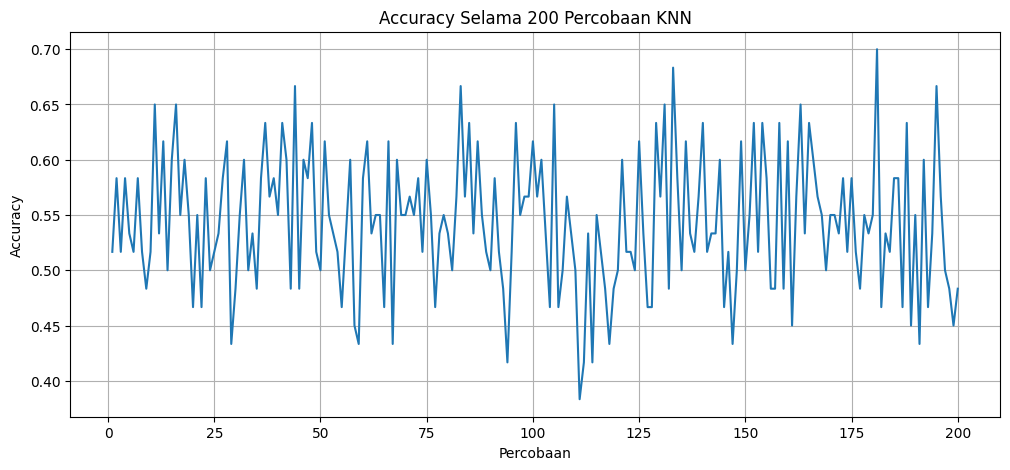

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(hasil_epoch["Percobaan"], hasil_epoch["Accuracy"])
plt.xlabel("Percobaan")
plt.ylabel("Accuracy")
plt.title("Accuracy Selama 200 Percobaan KNN")
plt.grid(True)
plt.show()

In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [28]:
y_pred = knn.predict(X_test)

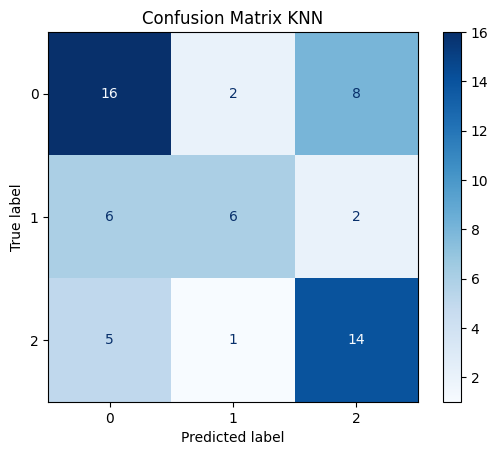

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix KNN")
plt.show()